Imports


In [2]:
import numpy as np
import pandas as pd
from sklearn.ensemble import RandomForestRegressor, BaggingRegressor
from sklearn.model_selection import train_test_split
from nltk.stem.snowball import SnowballStemmer

Week 9

Data exploration

Loading csv to pandas

In [3]:
attributes = pd.read_csv("attributes.csv/attributes.csv")
product_description = pd.read_csv("product_descriptions.csv/product_descriptions.csv")
sample_submission = pd.read_csv("sample_submission.csv/sample_submission.csv")
test = pd.read_csv("test.csv/test.csv", encoding="latin1")
train = pd.read_csv("train.csv/train.csv", encoding="latin1")


In [4]:
# attributes.head()
# product_description.head()
# sample_submission.head()
# test.head()
# train.head()

#1 What is the total number of product-query pairs in the training data?
print(train.count())
# answer 74067 pairs in total
#2 What is the number of unique products in the training data?
print(train["product_title"].nunique())

# answer 53489 product in total
#3 What are the two most occurring products in the training data and how often do they occur?
occurence_count = train["product_title"].value_counts()
print(occurence_count)
# answer Lithonia Lighting All Season 4 ft. 2-Light Grey T8 Strip Fluorescent Shop Light and Pressure-Treated Timber #2 Southern Yellow Pine (Common: 4 in. x 4 in. x 8 ft.; Actual: 3.56 in. x 3.56 in. x 96 in.)

# 4 Give the descriptive statistics for the relevance values (mean, median, standard deviation) in the training data.
print(train.describe())
print(train["relevance"].median())
# answer mean = 2.381634, median = 2.330000  and std = 0.533984 


id               74067
product_uid      74067
product_title    74067
search_term      74067
relevance        74067
dtype: int64
53489
product_title
Pressure-Treated Timber #2 Southern Yellow Pine (Common: 4 in. x 4 in. x 8 ft.; Actual: 3.56 in. x 3.56 in. x 96 in.)    21
Lithonia Lighting All Season 4 ft. 2-Light Grey T8 Strip Fluorescent Shop Light                                          21
2 in. x 4 in. x 96 in. Premium Kiln-Dried Whitewood Stud                                                                 18
Ryobi ONE+ 18-Volt Lithium-Ion Cordless Drill/Driver and Impact Driver Kit (2-Tool)                                      17
Custom Building Products VersaBond Gray 50 lb. Fortified Thin-Set Mortar                                                 17
                                                                                                                         ..
Atlantic Windowpane 576 CD or 192 DVD Blu-Ray or Games Maple Sliding Glass Door Media Cabinet               

     product_uid            name                           value
9       100001.0  MFG Brand Name              Simpson Strong-Tie
37      100002.0  MFG Brand Name  BEHR Premium Textured DeckOver
69      100003.0  MFG Brand Name                        STERLING
93      100004.0  MFG Brand Name                     Grape Solar
122     100005.0  MFG Brand Name                           Delta
4287
value
Unbranded                     2954
Hampton Bay                   1723
KOHLER                        1389
Everbilt                      1381
Home Decorators Collection    1275
GE                             987
Name: count, dtype: int64


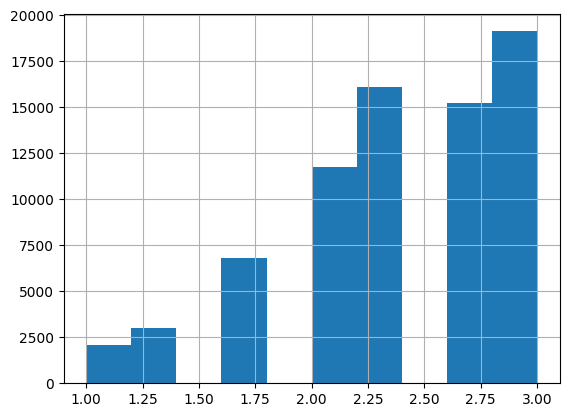

In [5]:
# 5 Show a histogram or boxplot of the distribution of relevance values in the training data
train['relevance'].hist(bins=10)

# answer is in output
# 6 What are the top-5 most occurring brand names in the product attributes?
#MFG Brand Name (brand name) and is in name
brandpd = attributes[attributes["name"].str.contains("MFG Brand Name", na=False)]
print(brandpd.head())
print(brandpd["value"].nunique())
occurence_brand = brandpd["value"].value_counts()
# most are unbranded but that isnt a brand
occurence_brand_5 = occurence_brand.head(6)
print(occurence_brand_5)
# Hampton Bay, KOHLER, Everbilt, Home Decorators Collecton and GE

Base-Line Model

In [6]:

# snowball stemmer is a text-processin tool to reduce words to their base or root form
stemmer = SnowballStemmer('english')

# load the csv's as pandas
df_train = pd.read_csv('train.csv/train.csv', encoding="ISO-8859-1")
df_test = pd.read_csv('test.csv/test.csv', encoding="ISO-8859-1")
# df_attr = pd.read_csv('../input/attributes.csv')
df_pro_desc = pd.read_csv('product_descriptions.csv/product_descriptions.csv')

# gets the number of rows in training df
num_train = df_train.shape[0]

# return a string into its base stemmer form
def str_stemmer(s):
	return " ".join([stemmer.stem(word) for word in s.lower().split()])

# counts how many times words of str1 come for in str2
def str_common_word(str1, str2):
	return sum(int(str2.find(word)>=0) for word in str1.split())

# combines both datasets (axis = row) and resets index
df_all = pd.concat((df_train, df_test), axis=0, ignore_index=True)
# merges on id
df_all = pd.merge(df_all, df_pro_desc, how='left', on='product_uid')

# changing values with its base term
df_all['search_term'] = df_all['search_term'].map(lambda x:str_stemmer(x))
df_all['product_title'] = df_all['product_title'].map(lambda x:str_stemmer(x))
df_all['product_description'] = df_all['product_description'].map(lambda x:str_stemmer(x))

# getting the lengh of the search term (amount of words in the search term)
df_all['len_of_query'] = df_all['search_term'].map(lambda x:len(x.split())).astype(np.int64)

df_all['product_info'] = df_all['search_term']+"\t"+df_all['product_title']+"\t"+df_all['product_description']
 
# gives how many words of the search terms appear in the product title
# gives how many words of the search terms appear in the product description
df_all['word_in_title'] = df_all['product_info'].map(lambda x:str_common_word(x.split('\t')[0],x.split('\t')[1]))
df_all['word_in_description'] = df_all['product_info'].map(lambda x:str_common_word(x.split('\t')[0],x.split('\t')[2]))

# drop unnecessary columns
df_all = df_all.drop(['search_term','product_title','product_description','product_info'],axis=1)

# split df back to train and test
# extract the ids
df_train = df_all.iloc[:num_train]
df_test = df_all.iloc[num_train:]
id_test = df_test['id']

# create training and testing
y_train = df_train['relevance'].values
X_train = df_train.drop(['id','relevance'],axis=1).values
X_test = df_test.drop(['id','relevance'],axis=1).values

#RFR is an ensemble method that makes decisions tree (number of trees, how far tree can grow, fix for randomness)
#BR training multiple RFR on a subset of the data (number of models, amount of sample each models has, fix for randomness)
rf = RandomForestRegressor(n_estimators=15, max_depth=6, random_state=0)
clf = BaggingRegressor(rf, n_estimators=45, max_samples=0.1, random_state=25)
clf.fit(X_train, y_train)
y_pred = clf.predict(X_test)

# make a pd dataframe as a csv
# it has product id and how relevant the product is for the search term
pd.DataFrame({"id": id_test, "relevance": y_pred}).to_csv('submission.csv',index=False)

Week 10

Evaluation

MSE and Split


In [8]:
train_X = df_train.drop(['id','relevance'], axis=1) # id is not a relevant feature
train_y = df_train['relevance']

X_train, X_test, y_train, y_test = train_test_split(train_X, train_y, random_state=44, test_size=0.2)

clf.fit(X_train, y_train)
y_pred = clf.predict(X_test)

first_RMSE = np.sqrt(((y_pred - y_test) ** 2).mean())
print(first_RMSE)

0.4802239961345922


Evaluate without Stemming

In [10]:
num_train = train.shape[0]

# counts how many times words of str1 come for in str2
def str_common_word(str1, str2):
	return sum(int(str2.find(word)>=0) for word in str1.split())

# combines both datasets (axis = row) and resets index
df_all = pd.concat((train, test), axis=0, ignore_index=True)
# merges on id
df_all = pd.merge(df_all, product_description, how='left', on='product_uid')

# lower is used incase op capitalisation
df_all['search_term'] = df_all['search_term'].str.lower()
df_all['product_title'] = df_all['product_title'].str.lower()
df_all['product_description'] = df_all['product_description'].str.lower()

# getting the lengh of the search term (amount of words in the search term)
df_all['len_of_query'] = df_all['search_term'].map(lambda x:len(x.split())).astype(np.int64)

df_all['product_info'] = df_all['search_term']+"\t"+df_all['product_title']+"\t"+df_all['product_description']
 
# gives how many words of the search terms appear in the product title
# gives how many words of the search terms appear in the product description
df_all['word_in_title'] = df_all['product_info'].map(lambda x:str_common_word(x.split('\t')[0],x.split('\t')[1]))
df_all['word_in_description'] = df_all['product_info'].map(lambda x:str_common_word(x.split('\t')[0],x.split('\t')[2]))

# drop unnecessary columns
df_all = df_all.drop(['search_term','product_title','product_description','product_info'],axis=1)

# split df back to train and test
# extract the ids
df_train = df_all.iloc[:num_train]
df_test = df_all.iloc[num_train:]
id_test = df_test['id']

# create training and testing
train_y = df_train['relevance'].values
train_X = df_train.drop(['id','relevance'],axis=1).values
X_train, X_test, y_train, y_test = train_test_split(train_X, train_y, random_state=44, test_size=0.2)


#RFR is an ensemble method that makes decisions tree (number of trees, how far tree can grow, fix for randomness)
#BR training multiple RFR on a subset of the data (number of models, amount of sample each models has, fix for randomness)
rf = RandomForestRegressor(n_estimators=15, max_depth=6, random_state=0)
clf = BaggingRegressor(rf, n_estimators=45, max_samples=0.1, random_state=25)
clf.fit(X_train, y_train)
y_pred = clf.predict(X_test)

first_RMSE = np.sqrt(((y_pred - y_test) ** 2).mean())
print(first_RMSE)

0.49058754526986437
